# Setup

In [ ]:
# Imports
import numpy as np
import os
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# Enter the foldername in your Drive where you have saved the unzipped
FOLDERNAME = 'CompNeuroFinalProject/code'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

Mounted at /content/drive


# Data Loading

In [ ]:
MEEG_data_path = '/content/drive/MyDrive/CompNeuroFinalProject/Code_5.15/MEEG'

In [ ]:
# from meeg_dataset import load_meeg_raw, MEEGDataset, N_CHANNELS, N_SUBJECTS, N_TRIALS

# # Load raw MEEG data
# all_samples = load_meeg_raw(
#     root          = MEEG_data_path, # use MEEG datapath defined above
#     window_sec    = 4.0,    # window length in seconds
#     overlap_sec   = 2.0,    # overlap between consecutive windows
#     apply_preproc = True,   # set False if files are already preprocessed
# )

# print(f"Total samples: {len(all_samples)}") # 17920

In [ ]:
from meeg_dataset import load_meeg_raw, MEEGDataset, N_CHANNELS, N_SUBJECTS, N_TRIALS
import pickle
# To avoid reprocessing the raw MEEG data every time,
# we can save the `all_samples` object
# (which contains the loaded and preprocessed data) to a file.
# We'll use `pickle` for this, as it handles Python objects well.
# This way, if the pickle file already exists,
# we can load directly from it, skipping the `load_meeg_raw` step.

saved_data_path = os.path.join(MEEG_data_path, 'all_samples.pkl')

if os.path.exists(saved_data_path):
    print(f"Loading preprocessed data from {saved_data_path}")
    with open(saved_data_path, 'rb') as f:
        all_samples = pickle.load(f)
else:
    # Load raw MEEG data
    print(f"Loading raw MEEG data from {MEEG_data_path}")
    all_samples = load_meeg_raw(
      root          = MEEG_data_path, # use MEEG datapath defined above
      window_sec    = 4.0,    # window length in seconds
      overlap_sec   = 2.0,    # overlap between consecutive windows
      apply_preproc = True,   # set False if files are already preprocessed
    )
    print(f"Total samples: {len(all_samples)}") # 17920
    print(f"Saving all_samples to {saved_data_path}")
    with open(saved_data_path, 'wb') as f:
        pickle.dump(all_samples, f)


Loading raw MEEG data from /content/drive/MyDrive/CompNeuroFinalProject/Code_5.15/MEEG
Loaded 32 subjects → 17920 windows  (4.0s / 2.0s overlap / 800 samples @ 200 Hz)
Label dist: HVHA=4480(25%)  HVLA=4480(25%)  LVHA=4480(25%)  LVLA=4480(25%)

Total samples: 17920
Saving all_samples to /content/drive/MyDrive/CompNeuroFinalProject/Code_5.15/MEEG/all_samples.pkl


In [ ]:
# example data point in form
# {
# "subject_id" : str           | e.g. "subject_1"
# "trial_idx"  : int           | 0-based within subject  (0-19)
# "segment"    : np.ndarray    | (32, win_samples) @ 200 Hz, float32
# "label"      : int           | 0-3  (HVHA / HVLA / LVHA / LVLA)
# "valence"    : int           | 0 or 1
# "arousal"    : int           | 0 or 1
# }
print(all_samples[0])

{'subject_id': 'sample_1', 'trial_idx': 0, 'segment': array([[ 3.1195905e-06, -5.0010430e-03, -6.5727876e-03, ...,
         9.4492161e-06,  8.3882323e-06,  7.2487251e-06],
       [ 2.1805488e-06, -1.0555039e-02, -1.3872127e-02, ...,
        -3.5836852e-06, -2.2396202e-06, -6.8144647e-07],
       [ 2.0528530e-06, -6.9692186e-03, -9.1586262e-03, ...,
        -9.7744675e-08,  1.9461647e-06,  4.8034285e-06],
       ...,
       [-1.5091348e-06, -5.5999868e-03, -7.3584467e-03, ...,
        -3.1926761e-06, -7.2029779e-06, -8.7918170e-06],
       [-5.8848195e-07, -3.2140641e-03, -4.2228685e-03, ...,
        -5.5917330e-06, -9.4432162e-06, -9.2992286e-06],
       [-3.5122321e-07, -6.7689838e-03, -8.8964235e-03, ...,
         2.6905786e-07, -3.0477204e-07, -1.9780948e-06]], dtype=float32), 'label': 0, 'valence': 1, 'arousal': 1}


In [ ]:
# get the adjacency matrix for the GNN
# prune it by electrode distance
adj = MEEGDataset.electrode_adjacency(threshold=0.5)  # (32, 32)
# this stores all the edges in the adjacency matrix
# with row 1 = source and row 2 = destination
# E = 128
edge_index = adj.nonzero(as_tuple=False).t().contiguous()    # (2, E)

print(f"Nodes: 32, Edges: {edge_index.shape[1]}")

Nodes: 32, Edges: 128


# Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DGNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W   = nn.Linear(in_dim, out_dim, bias=False)
        self.W_a = nn.Linear(in_dim, in_dim,  bias=False)

    def forward(self, x):
        # x: (B, 32, in_dim)
        # remove F.relu here — let softmax handle the normalization
        A = F.softmax(self.W_a(x) @ x.transpose(-1, -2), dim=-1)  # (B, 32, 32)
        return F.elu(A @ self.W(x))   # also swap F.relu → F.elu to avoid dying ReLUs on output

class EEGGNN(nn.Module):
    def __init__(self, in_dim=5, hidden_dim=32, num_classes=4):
        super().__init__()

        self.dgnn1 = DGNNLayer(in_dim, hidden_dim)
        self.dgnn2 = DGNNLayer(hidden_dim, hidden_dim)
        self.dgnn3 = DGNNLayer(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
             # predict the label (4 options) and use that to derive valence/arousal later
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (B, 32, 5)
        # the 5 here is the different bands of brain waves
        h = self.dgnn1(x)
        h = self.dgnn2(h)
        h = self.dgnn3(h)

        return self.classifier(h)  # (B, 4)

# Training / Testing Methods

In [ ]:
# Get all unique subject IDs and sort them to ensure consistent ordering
all_subject_ids = sorted(list(set([s['subject_id'] for s in all_samples])))

In [ ]:
from meeg_dataset import compute_psd
from splits import get_cross_trial_splits

def data_format(samples, subject_limit):
    # get the first 1...subjectlimit subjects
    selected_subject_ids = set(all_subject_ids[:subject_limit])
    # these are the cross subjects
    new_subject_samples  = [s for s in samples if s['subject_id'] not in selected_subject_ids]
    # these are the within_subjects
    within_samples       = [s for s in samples if s['subject_id'] in selected_subject_ids]

    # to get within subjects splits
    # shuffle trials before splitting so classes are balanced in training and test
    # ignore val
    train_s, _val_s, test_s = get_cross_trial_splits(
        within_samples,
        train_trials  = 16,
        val_trials    = 0,
        test_trials   = 4,
        shuffle_trials = True,
        seed          = 42
    )

    # format the data into x, y with segment -> [label, valuence, arousal]
    within_x_train = np.stack([compute_psd(s["segment"]) for s in train_s])
    within_y_train = np.stack([[s["label"], s["valence"], s["arousal"]] for s in train_s])
    within_x_test  = np.stack([compute_psd(s["segment"]) for s in test_s])
    within_y_test  = np.stack([[s["label"], s["valence"], s["arousal"]] for s in test_s])

    new_x_test     = np.stack([compute_psd(s["segment"]) for s in new_subject_samples])
    new_y_test     = np.stack([[s["label"], s["valence"], s["arousal"]] for s in new_subject_samples])

    # normalize using train stats
    mean = within_x_train.mean(axis=0, keepdims=True)
    std  = within_x_train.std(axis=0,  keepdims=True) + 1e-8
    within_x_train = (within_x_train - mean) / std
    within_x_test  = (within_x_test  - mean) / std
    new_x_test     = (new_x_test     - mean) / std

    # make sure emotion labels are distributed well in the test data
    # print("Test label distribution:")
    # print("Emotion:", np.bincount(within_y_test[:, 0]))
    # print("Valence:", np.bincount(within_y_test[:, 1]))
    # print("Arousal:", np.bincount(within_y_test[:, 2]))

    return within_x_train, within_y_train, within_x_test, within_y_test, new_x_test, new_y_test


In [ ]:
import numpy as np
import torch
import torch.nn as nn

# use cross entropy loss
criterion = nn.CrossEntropyLoss()

def train_eval(model, x, y, optimizer=None, batch_size=64, device="cuda"):
  """
  If optimizer is provided:
      train mode

  If optimizer is None:
      eval mode

  Returns:
      {
          loss,
          label_acc,
          valence_acc,
          arousal_acc
      }
  """

  # move to tensor from np arrays
  x = torch.tensor(x, dtype=torch.float32)
  y = torch.tensor(y, dtype=torch.long)

  # set the model in the correct mode
  if optimizer is None:
      model.eval()
  else:
      model.train()
      # shuffle the data randomly
      perm = np.random.permutation(len(x))
      x, y = x[perm], y[perm]

  total_loss = 0
  total_samples = 0

  correct_label = 0
  correct_valence = 0
  correct_arousal = 0

  for start in range(0, len(x), batch_size):
    # get the next batch of samples and labels
    # and move to gpu
    xb = x[start:start+batch_size].to(device)
    emotion_labels = y[start:start+batch_size, 0].to(device)
    valence_labels = y[start:start+batch_size, 1].to(device)
    arousal_labels = y[start:start+batch_size, 2].to(device)

    # make gradients if there is an optimizer
    with torch.set_grad_enabled(optimizer is not None):
        # forward pass
        logits = model(xb)
        # use cross entropy to compare model output and emotion label
        # (B, 4)
        loss = criterion(
            logits,
            emotion_labels
        )

        # this is what we'll use to improve the weights
        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


    # but when reporting accuracies
    # report valence and arousal accuracy too

    # use the class with highest prediction as the decided emotion
    # (B, 1)
    pred_label = logits.argmax(dim=1)

    # derive valence from emotion prediction
    # 0 HVHA -> high valence
    # 1 HVLA -> high valence
    # vs
    # 2 LVHA -> low valence
    # 3 LVLA -> low valence
    pred_valence = (pred_label <= 1).long()

    # derive arousal from emotion prediction
    # 0 HVHA -> high arousal
    # 2 LVHA -> high arousal
    # vs
    # 1 HVLA -> low arousal
    # 3 LVLA -> low arousal
    pred_arousal = (
        (pred_label == 0) |
        (pred_label == 2)
    ).long()

    # see if we got the answer right for any sample in batch
    correct_label += (
        pred_label == emotion_labels
    ).sum().item()
    # see if we got the answer right for any sample in batch
    correct_valence += (
        pred_valence == valence_labels
    ).sum().item()
    # see if we got the answer right for any sample in batch
    correct_arousal += (
        pred_arousal == arousal_labels
    ).sum().item()

    # store the total loss weighted by the batch size
    total_loss += loss.item() * len(xb)
    # increment the number of samples seen by batch size
    total_samples += len(xb)

  return {
    "loss": total_loss / total_samples,
    "label_acc": correct_label / total_samples,
    "valence_acc": correct_valence / total_samples,
    "arousal_acc": correct_arousal / total_samples,
  }

In [ ]:
import matplotlib.pyplot as plt

def plot_training_acc(data, subject_limit):
  """
  plot the loss over epochs
  plot the accuracy for emotion, valence, arousal over epochs
  with data in format
  [
    {
      "loss": total_loss / total_samples,
      "label_acc": correct_label / total_samples,
      "valence_acc": correct_valence / total_samples,
      "arousal_acc": correct_arousal / total_samples,
    },
    # ... for each epoch
  ]
  """
  # consolidate the data from dictionary to arrays
  epochs = range(len(data))
  losses = [d['loss'] for d in data]
  label_accs = [d['label_acc'] for d in data]
  valence_accs = [d['valence_acc'] for d in data]
  arousal_accs = [d['arousal_acc'] for d in data]

  plt.figure(figsize=(10, 5))
  plt.plot(epochs, losses, label="Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(f"Training Loss over Epochs (Subject Limit: {subject_limit})")
  plt.legend()
  plt.grid(True)
  plt.show()

  plt.figure(figsize=(10, 5))
  plt.plot(epochs, label_accs, label="Emotion Acc")
  plt.plot(epochs, valence_accs, label="Valence Acc")
  plt.plot(epochs, arousal_accs, label="Arousal Acc")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title(f"Training Accuracies over Epochs (Subject Limit: {subject_limit})")
  plt.legend()
  plt.grid(True)
  plt.ylim(0, 1) # Accuracies are between 0 and 1
  plt.show()

In [ ]:
# train 3 models and gather results
def train_a_model(subject_limit):
  within_x_train, within_y_train, within_x_test, within_y_test, new_x_test, new_y_test = data_format(all_samples, subject_limit)
  # make model
  model = EEGGNN().to("cuda")
  # make optimizer
  optimizer = optim.Adam(model.parameters(), lr=0.003)
  # decrease learning rate if we hit a plateau
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='min', factor=0.5, patience=3
  )

  path = "/content/drive/MyDrive/CompNeuroFinalProject/code/"
  # give the model a name based on the subject type
  name = "GNN_"+str(subject_limit)+".pth"

  # Ensure the directory for saving weights exists
  output_dir = os.path.dirname(path + name)
  if output_dir: # if it does exist, link to it
      os.makedirs(output_dir, exist_ok=True)

  # load in the GNN's weigths
  if os.path.exists(path + name):
    print("Loading weights")
    model.load_state_dict(torch.load(path + name))
  else:
    print("No previous weights, starting again")

  within_train_res_accs = [] # holds a {} for each epoch
  for epoch in range(60):
    # train using within_x / y train
    within_train_res = train_eval(model, within_x_train, within_y_train, optimizer)
    print(f"Epoch {epoch}: {within_train_res}")
    within_train_res_accs.append(within_train_res)

    scheduler.step(within_train_res["loss"])

  # save the model
  torch.save(model.state_dict(), path + name)
  print("saved model!")

  # plot the training accuracy over epochs
  plot_training_acc(within_train_res_accs, subject_limit)

  # store the dictionary w the best emotion accuracy we found
  best_within_train_acc = max(within_train_res_accs, key=lambda x: x["label_acc"])

  # test the model
  # test using within_x / y test to get within subject accuracy
  within_test_res = train_eval(model, within_x_test, within_y_test, None)
  # test using new_x / y test to get cross subject accuracy
  new_test_res = train_eval(model, new_x_test, new_y_test, None)

  return {
    "subject_limit": subject_limit,
    "within_train_res": best_within_train_acc,
    "within_test_res": within_test_res,
    "new_test_res": new_test_res
  }



── Cross-trial split ──
  train: 160 trials → 4480 windows
  val:   0 trials → 0 windows
  test:  40 trials → 1120 windows
  train labels: HVHA=1120(25%)  HVLA=1064(24%)  LVHA=1288(29%)  LVLA=1008(22%)
  test labels: HVHA=280(25%)  HVLA=336(30%)  LVHA=112(10%)  LVLA=392(35%)

Test label distribution:
Emotion: [280 336 112 392]
Valence: [504 616]
Arousal: [728 392]
Loading weights
Epoch 0: {'loss': 1.3434743131910052, 'label_acc': 0.32857142857142857, 'valence_acc': 0.5363839285714286, 'arousal_acc': 0.5877232142857143}
Epoch 1: {'loss': 1.335405148778643, 'label_acc': 0.33214285714285713, 'valence_acc': 0.5408482142857143, 'arousal_acc': 0.5832589285714286}
Epoch 2: {'loss': 1.3383770823478698, 'label_acc': 0.32901785714285714, 'valence_acc': 0.5314732142857143, 'arousal_acc': 0.5828125}
Epoch 3: {'loss': 1.335850192819323, 'label_acc': 0.34017857142857144, 'valence_acc': 0.5366071428571428, 'arousal_acc': 0.5993303571428571}
Epoch 4: {'loss': 1.3463071499552046, 'label_acc': 0.322544

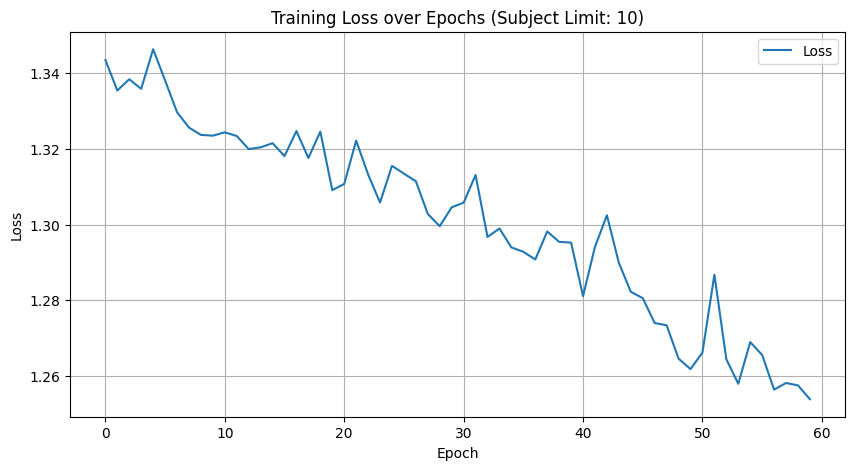

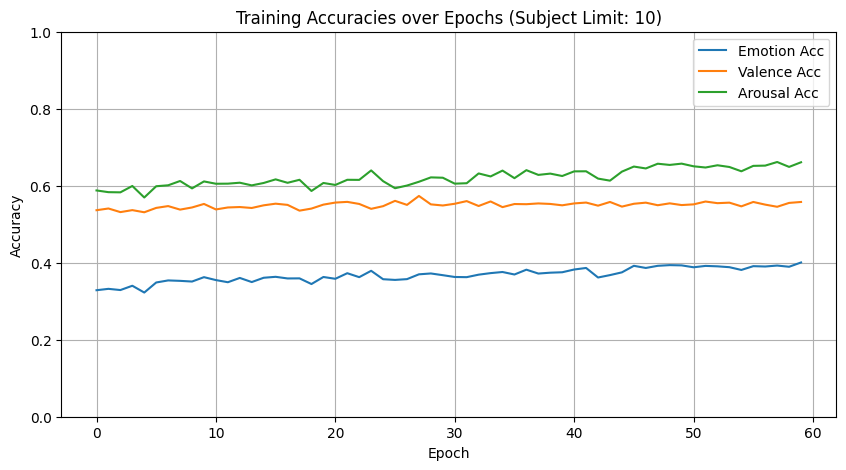

In [ ]:
res10 = train_a_model(10)


── Cross-trial split ──
  train: 320 trials → 8960 windows
  val:   0 trials → 0 windows
  test:  80 trials → 2240 windows
  train labels: HVHA=2324(26%)  HVLA=2128(24%)  LVHA=2352(26%)  LVLA=2156(24%)
  test labels: HVHA=476(21%)  HVLA=672(30%)  LVHA=448(20%)  LVLA=644(29%)

Loading weights
Epoch 0: {'loss': 1.3038662544318609, 'label_acc': 0.37354910714285716, 'valence_acc': 0.5662946428571428, 'arousal_acc': 0.6200892857142857}
Epoch 1: {'loss': 1.2835641545908791, 'label_acc': 0.3908482142857143, 'valence_acc': 0.5780133928571428, 'arousal_acc': 0.6272321428571429}
Epoch 2: {'loss': 1.282614493370056, 'label_acc': 0.38560267857142855, 'valence_acc': 0.5779017857142857, 'arousal_acc': 0.6239955357142857}
Epoch 3: {'loss': 1.2937430509499142, 'label_acc': 0.38582589285714286, 'valence_acc': 0.5724330357142857, 'arousal_acc': 0.62734375}
Epoch 4: {'loss': 1.286573336805616, 'label_acc': 0.38270089285714287, 'valence_acc': 0.5744419642857143, 'arousal_acc': 0.6248883928571428}
Epoch 5

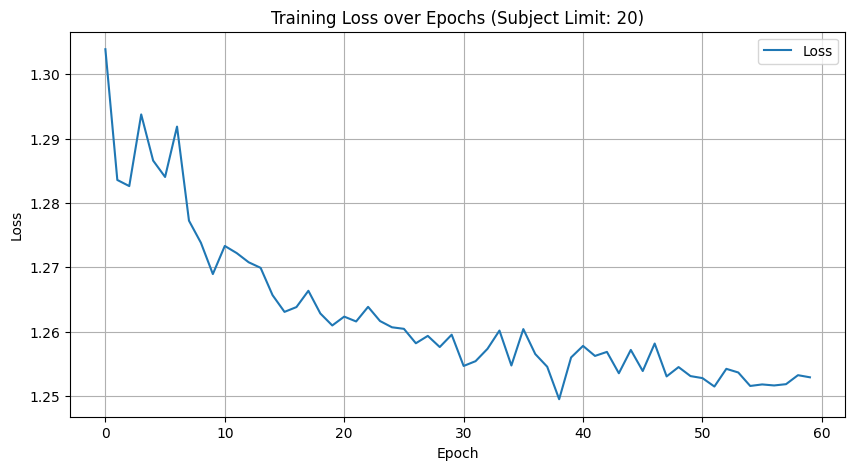

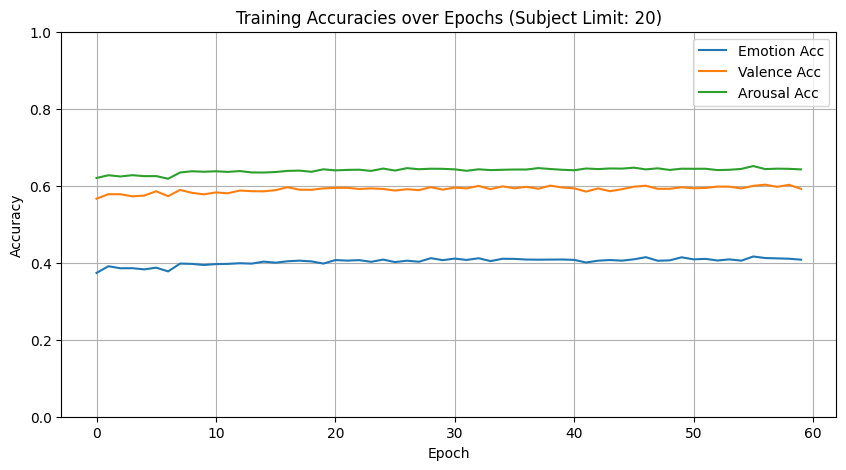

In [ ]:
res20 = train_a_model(20)


── Cross-trial split ──
  train: 480 trials → 13440 windows
  val:   0 trials → 0 windows
  test:  120 trials → 3360 windows
  train labels: HVHA=3472(26%)  HVLA=3248(24%)  LVHA=3276(24%)  LVLA=3444(26%)
  test labels: HVHA=728(22%)  HVLA=952(28%)  LVHA=924(28%)  LVLA=756(22%)

Loading weights
Epoch 0: {'loss': 1.294286824975695, 'label_acc': 0.38095238095238093, 'valence_acc': 0.5508184523809524, 'arousal_acc': 0.6529017857142857}
Epoch 1: {'loss': 1.2935890640531267, 'label_acc': 0.3848958333333333, 'valence_acc': 0.5514136904761905, 'arousal_acc': 0.6555803571428571}
Epoch 2: {'loss': 1.2945291286423093, 'label_acc': 0.38095238095238093, 'valence_acc': 0.5467261904761904, 'arousal_acc': 0.6590029761904762}
Epoch 3: {'loss': 1.2869560707183112, 'label_acc': 0.3867559523809524, 'valence_acc': 0.5494791666666666, 'arousal_acc': 0.6638392857142857}
Epoch 4: {'loss': 1.3007540328162057, 'label_acc': 0.3795386904761905, 'valence_acc': 0.5498511904761905, 'arousal_acc': 0.6526785714285714

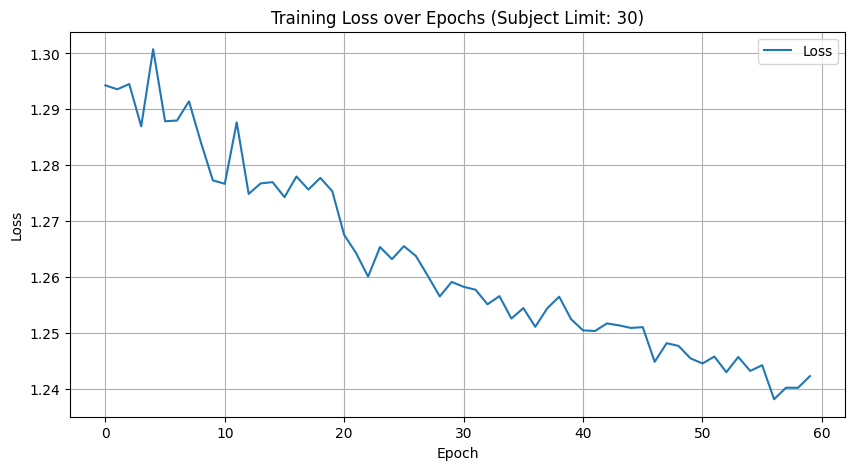

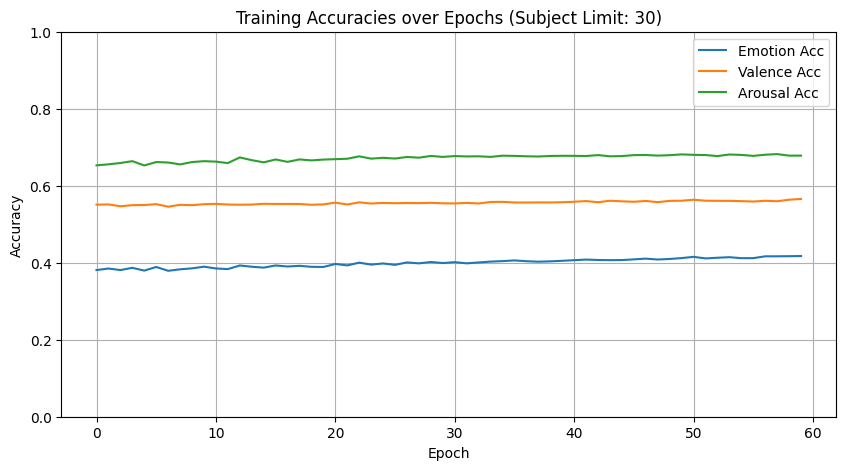

In [ ]:
res30 = train_a_model(30)

# Plot the results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_results(res):
  """
  takes in the results for a subject limit
  and plots the results
  """
  # and one section for within train, within test and new test
  # in format {
  #   "loss": total_loss / total_samples,
  #   "label_acc": correct_label / total_samples,
  #   "valence_acc": correct_valence / total_samples,
  #   "arousal_acc": correct_arousal / total_samples,
  # }
  subject_limit = res["subject_limit"]
  within_train_res = res["within_train_res"]
  within_test_res = res["within_test_res"]
  new_test_res = res["new_test_res"]

  # in each section there will be 3 bars (1 for emotion, valence, arousal acc)
  accuracy_names = ['Emotion', 'Valence', 'Arousal']

  data_to_plot = {
      "Within Train": [within_train_res["label_acc"], within_train_res["valence_acc"], within_train_res["arousal_acc"]],
      "Within Test": [within_test_res["label_acc"], within_test_res["valence_acc"], within_test_res["arousal_acc"]],
      "New Test": [new_test_res["label_acc"], new_test_res["valence_acc"], new_test_res["arousal_acc"]]
  }

  for plot_title, accuracies in data_to_plot.items():
      fig, ax = plt.subplots(figsize=(8, 6))
      bar_positions = np.arange(len(accuracy_names))
      ax.bar(bar_positions, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])

      ax.set_ylabel('Accuracy')
      ax.set_title(f'{plot_title} for Subject Limit {subject_limit}')
      ax.set_xticks(bar_positions)
      ax.set_xticklabels(accuracy_names)
      ax.set_ylim(0, 1) # Accuracies are between 0 and 1
      ax.grid(axis='y', linestyle='--', alpha=0.7)

      # Add text labels on top of each bar
      for i, acc in enumerate(accuracies):
          ax.text(bar_positions[i], acc + 0.02, f'{acc:.2f}', ha='center', va='bottom')

      plt.tight_layout()
      plt.show()

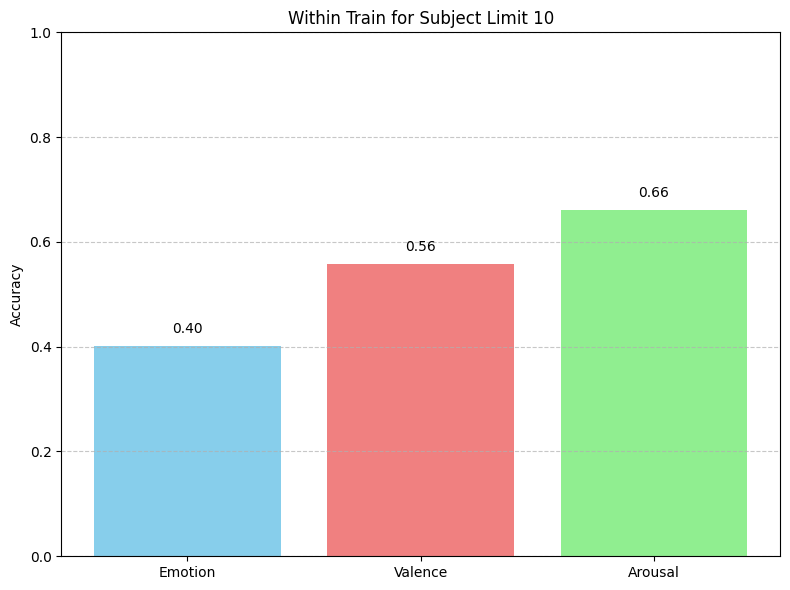

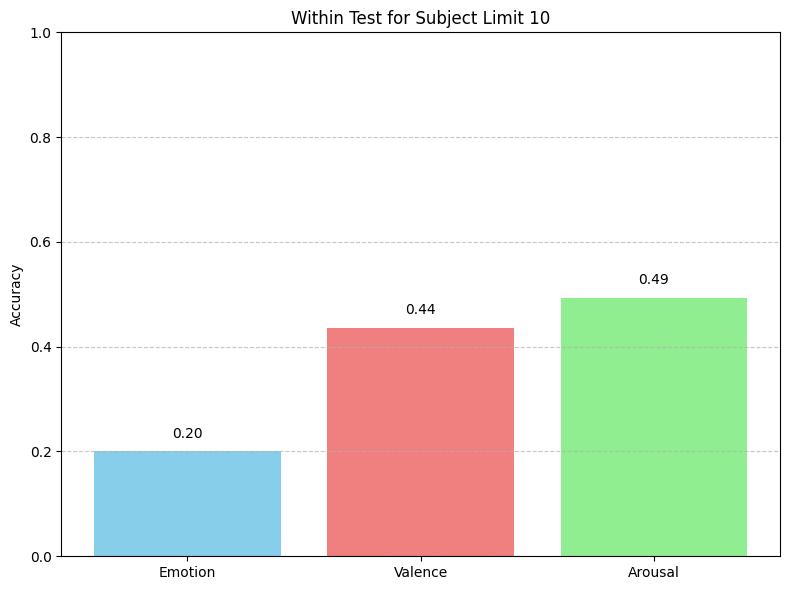

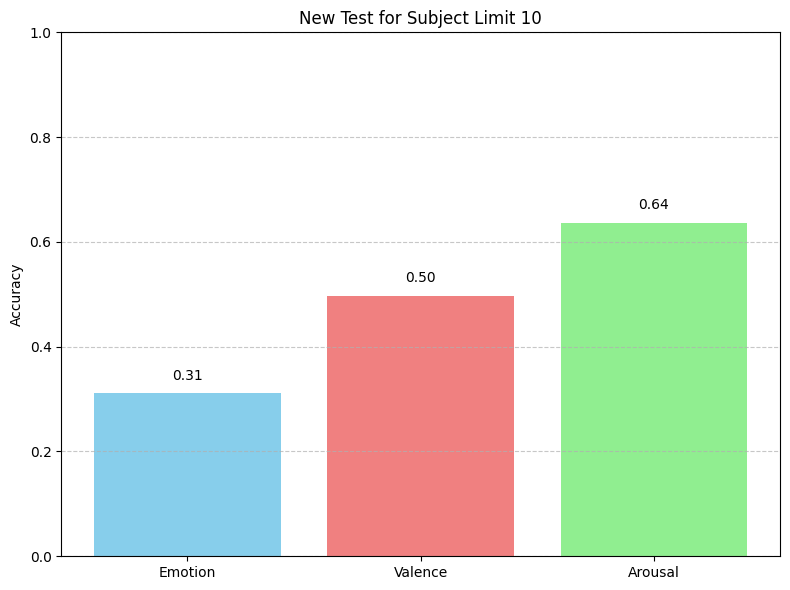

In [ ]:
plot_results(res10)

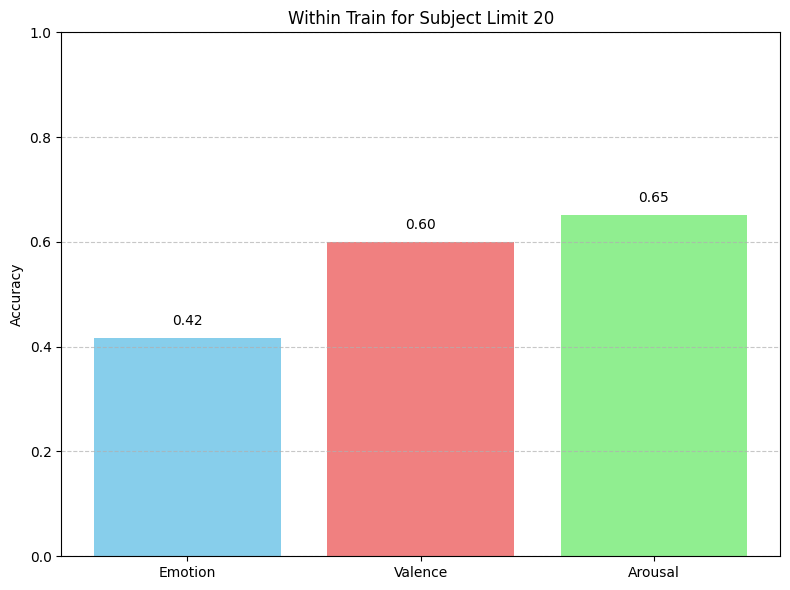

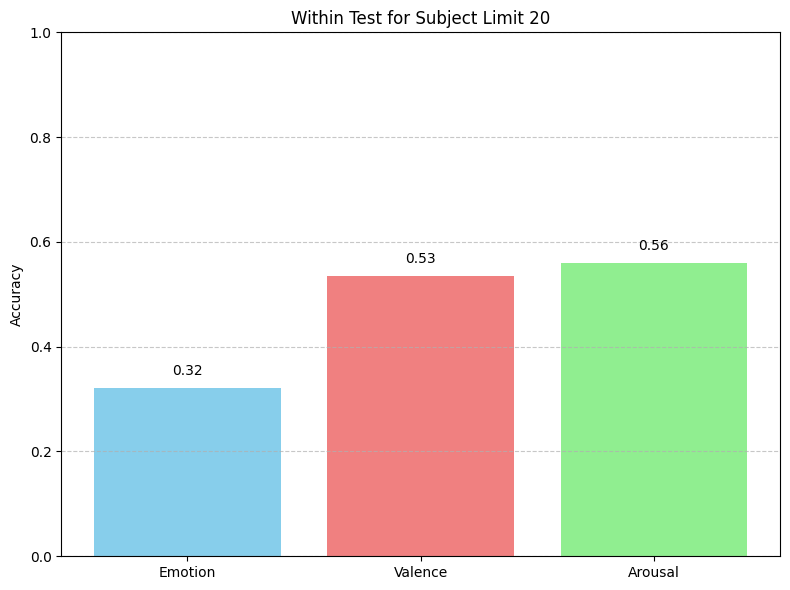

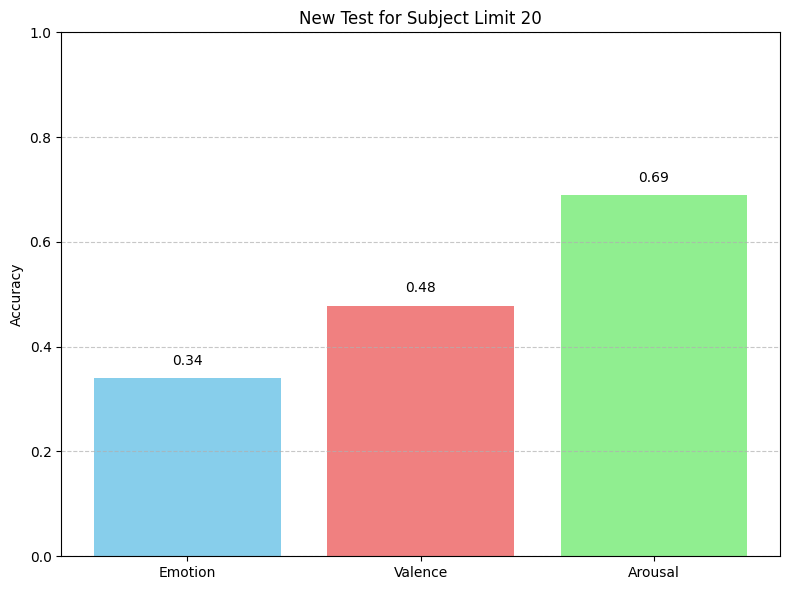

In [ ]:
plot_results(res20)

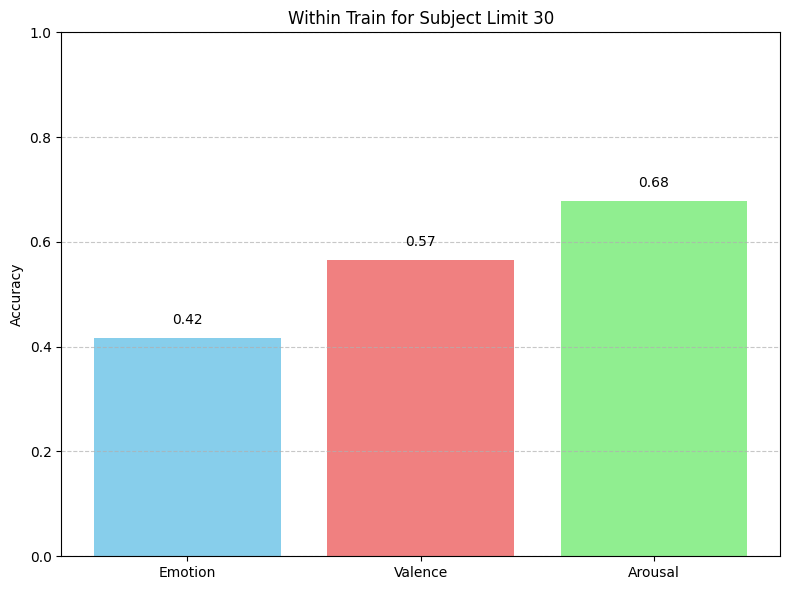

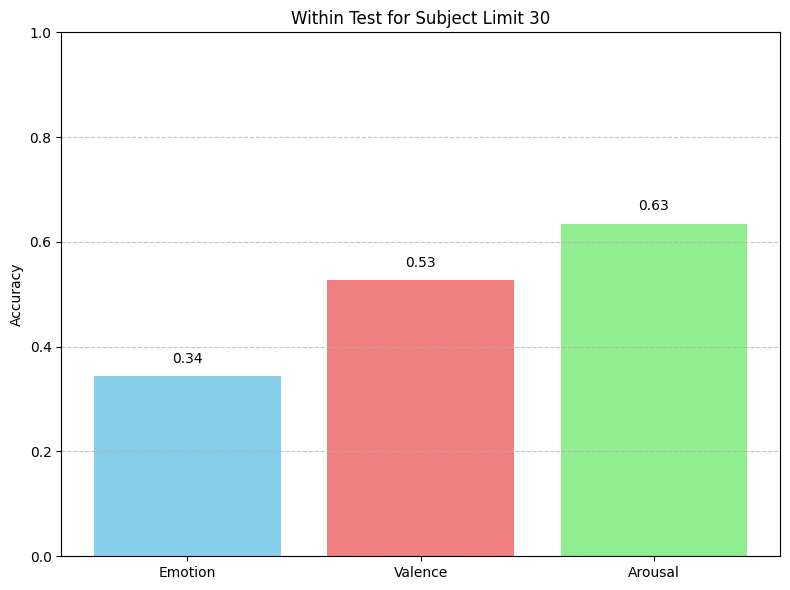

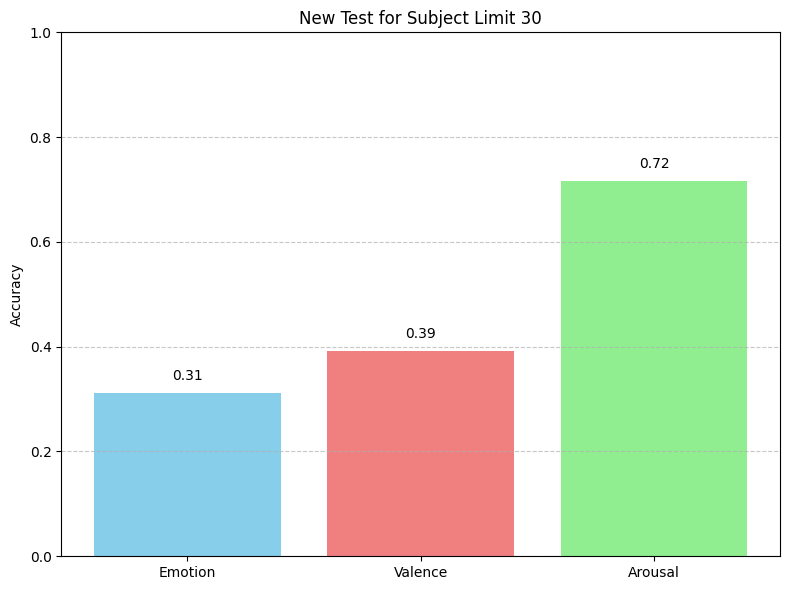

In [ ]:
plot_results(res30)